In [5]:
import pandas as pd
import re

def parse_can_log(file_path):
    """Parse CAN log file and return a pandas DataFrame"""
    data = []
    
    with open(file_path, 'r') as f:
        for line in f:
            # Extract fields using regex
            match = re.search(r'Timestamp:\s([\d.]+)\s+ID:\s(\w+)\s+(\w+)\s+DLC:\s(\d+)\s+(.*)', line)
            if match:
                timestamp, can_id, flags, dlc, hex_data = match.groups()
                data.append({
                    'Timestamp': float(timestamp),
                    'ID': can_id,
                    'Flags': flags,
                    'DLC': int(dlc),
                    'Data': hex_data.strip()
                })
    
    df = pd.DataFrame(data)
    return df

# Usage
df = parse_can_log('dataset\\normal_run_data\\normal_run_data.txt')
df["Attack"] = "R"
print(df)

           Timestamp    ID Flags  DLC                     Data Attack
0       1.479121e+09  0350   000    8  05 28 84 66 6d 00 00 a2      R
1       1.479121e+09  02c0   000    8  14 00 00 00 00 00 00 00      R
2       1.479121e+09  0430   000    8  00 00 00 00 00 00 00 00      R
3       1.479121e+09  04b1   000    8  00 00 00 00 00 00 00 00      R
4       1.479121e+09  01f1   000    8  00 00 00 00 00 00 00 00      R
...              ...   ...   ...  ...                      ...    ...
988866  1.479122e+09  02b0   000    5           ac 05 0c 07 7f      R
988867  1.479122e+09  0316   000    8  05 38 10 0c 38 28 01 7a      R
988868  1.479122e+09  018f   000    8  fe 31 00 00 00 4b 00 00      R
988869  1.479122e+09  0260   000    8  32 38 39 30 ff 93 59 1c      R
988870  1.479122e+09  02a0   000    8  20 00 75 1d 01 04 dd 00      R

[988871 rows x 6 columns]


In [6]:
def parse_can_csv(file_path):
    df_can = pd.read_csv(file_path, skipinitialspace=True)

    if 'ID dlc' in df_can.columns:
        df_can[['ID', 'DLC']] = df_can['ID dlc'].astype(str).str.split(r'\s+', n=1, expand=True)
        df_can = df_can.drop(columns=['ID dlc'])
    elif set(['Timestamp','ID','DLC','data1','data2','data3','data4','data5','data6','data7','data8','attack/nonattack']).issubset(df_can.columns):
        df_can = df_can.rename(columns={'attack/nonattack': 'Attack'})
    else:
        names = ['Timestamp','ID','DLC','data1','data2','data3','data4','data5','data6','data7','data8','Attack']
        df_can = pd.read_csv(file_path, header=None, names=names, skipinitialspace=True)

    unnamed = [c for c in df_can.columns if isinstance(c, str) and c.startswith('Unnamed')]
    if 'Attack' not in df_can.columns and unnamed:
        df_can = df_can.rename(columns={unnamed[-1]: 'Attack'})

    data_cols = sorted(
        [c for c in df_can.columns if isinstance(c, str) and c.lower().startswith('data')],
        key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 0
    )

    def build_data(row):
        try:
            dlc = int(row['DLC'])
        except Exception:
            dlc = 0

        values = []
        for col in data_cols[:min(dlc, len(data_cols))]:
            val = row.get(col)
            if pd.isna(val):
                continue
            s = str(val).strip()
            if s.lower() in ['', 'nan']:
                continue
            values.append(s)

        return ' '.join(values).strip()

    def infer_attack(row):
        attack = row.get('Attack')
        if isinstance(attack, str) and attack.strip():
            return attack

        try:
            dlc = int(row['DLC'])
        except Exception:
            dlc = 0

        for col in data_cols[min(dlc, len(data_cols)):]:
            val = row.get(col)
            if pd.isna(val):
                continue
            s = str(val).strip()
            if s.lower() in ['', 'nan']:
                continue
            if not re.fullmatch(r'[0-9A-Fa-f]{2}', s):
                return s

        return pd.NA

    if data_cols:
        df_can['Data'] = df_can.apply(build_data, axis=1)
        if 'Attack' not in df_can.columns:
            df_can['Attack'] = pd.NA
        df_can['Attack'] = df_can.apply(infer_attack, axis=1).combine_first(df_can['Attack'])
    else:
        df_can['Data'] = df_can.get('Data', '').astype(str).str.strip()
        if 'Attack' not in df_can.columns:
            df_can['Attack'] = pd.NA

    df_can['Timestamp'] = pd.to_numeric(df_can['Timestamp'], errors='coerce')
    df_can['DLC'] = pd.to_numeric(df_can['DLC'], errors='coerce').astype('Int64')

    return df_can[['Timestamp','ID','DLC','Data','Attack']]

In [7]:
import numpy as np

def sliding_windows_id_data(df, window_size=32, step=2, attack_label='T'):
    ids = df['ID'].to_numpy(dtype=object)
    data = df['Data'].to_numpy(dtype=object)
    attack = df['Attack'].to_numpy(dtype=object)

    n = len(df)
    num_windows = (n - window_size) // step + 1
    windows = []
    window_labels = []
    next_id_datas = []

    for start in range(0, n - window_size + 1, step):
        end = start + window_size
        windows.append(np.column_stack((ids[start:end], data[start:end])))
        next_id_datas.append(np.column_stack((ids[end], data[end])))
        window_labels.append(attack_label if 'T' in attack[start:end] else 'R')

    return windows, np.array(window_labels, dtype=object)


In [8]:
windowed_id_data0, window_attack_labels0 = sliding_windows_id_data(df[:555389], attack_label='D')


In [9]:
df_DoS = parse_can_csv(r'dataset\DoS_dataset.csv')
print(df_DoS.head())
windowed_id_data1, window_attack_labels1 = sliding_windows_id_data(df_DoS[:555389], attack_label='D')

del df_DoS

      Timestamp    ID  DLC                     Data Attack
0  1.478198e+09  0316    8  05 21 68 09 21 21 00 6f      R
1  1.478198e+09  018f    8  fe 5b 00 00 00 3c 00 00      R
2  1.478198e+09  0260    8  19 21 22 30 08 8e 6d 3a      R
3  1.478198e+09  02a0    8  64 00 9a 1d 97 02 bd 00      R
4  1.478198e+09  0329    8  40 bb 7f 14 11 20 00 14      R


In [10]:
df_Fuzzy = parse_can_csv(r'dataset\Fuzzy_dataset.csv')
print(df_Fuzzy.head())
windowed_id_data2, window_attack_labels2 = sliding_windows_id_data(df_Fuzzy[:555389], attack_label='F')

del df_Fuzzy

      Timestamp    ID  DLC                     Data Attack
0  1.478196e+09  0545    8  d8 00 00 8a 00 00 00 00      R
1  1.478196e+09  02b0    5           ff 7f 00 05 49      R
2  1.478196e+09  0002    8  00 00 00 00 00 01 07 15      R
3  1.478196e+09  0153    8  00 21 10 ff 00 ff 00 00      R
4  1.478196e+09  0130    8  19 80 00 ff fe 7f 07 60      R


In [11]:
df_gear = parse_can_csv(r'dataset\gear_dataset.csv')
print(df_gear.head())
windowed_id_data3, window_attack_labels3 = sliding_windows_id_data(df_gear[:555389], attack_label='S')

del df_gear

      Timestamp    ID  DLC                     Data Attack
0  1.478193e+09  0140    8  00 00 00 00 10 29 2a 24      R
1  1.478193e+09  02c0    8  15 00 00 00 00 00 00 00      R
2  1.478193e+09  0350    8  05 20 44 68 77 00 00 7e      R
3  1.478193e+09  0370    8  00 20 00 00 00 00 00 00      R
4  1.478193e+09  043f    8  10 40 60 ff 78 c4 08 00      R


In [12]:
df_RPM = parse_can_csv(r'dataset\RPM_dataset.csv')
print(df_RPM.head())
windowed_id_data4, window_attack_labels4 = sliding_windows_id_data(df_RPM[:555389], attack_label='S')

del df_RPM

      Timestamp    ID  DLC                     Data Attack
0  1.478191e+09  0316    8  05 22 68 09 22 20 00 75      R
1  1.478191e+09  018f    8  fe 3b 00 00 00 3c 00 00      R
2  1.478191e+09  0260    8  19 22 22 30 ff 8f 6e 3f      R
3  1.478191e+09  02a0    8  60 00 83 1d 96 02 bd 00      R
4  1.478191e+09  0329    8  dc b8 7e 14 11 20 00 14      R


In [13]:
# merge windowed datasets into the single variables used by downstream cells
windowed_id_data = []
windowed_id_data.extend(windowed_id_data0)
windowed_id_data.extend(windowed_id_data1)
windowed_id_data.extend(windowed_id_data2)
windowed_id_data.extend(windowed_id_data3)
windowed_id_data.extend(windowed_id_data4)

window_attack_labels = np.concatenate([
    window_attack_labels0,
    window_attack_labels1,
    window_attack_labels2,
    window_attack_labels3,
    window_attack_labels4
])



print("merged windows:", len(windowed_id_data), "merged labels:", window_attack_labels.shape)

merged windows: 1388395 merged labels: (1388395,)


In [14]:
print(len(windowed_id_data), windowed_id_data[:10])

1388395 [array([['0350', '05 28 84 66 6d 00 00 a2'],
       ['02c0', '14 00 00 00 00 00 00 00'],
       ['0430', '00 00 00 00 00 00 00 00'],
       ['04b1', '00 00 00 00 00 00 00 00'],
       ['01f1', '00 00 00 00 00 00 00 00'],
       ['0153', '00 00 00 ff 00 ff 00 00'],
       ['0002', '00 00 00 00 00 00 00 0a'],
       ['018f', 'fe 36 00 00 00 3c 00 00'],
       ['0130', '03 80 00 ff 21 80 00 9d'],
       ['0131', '00 80 00 00 2d 7f 00 97'],
       ['0140', '00 00 00 00 14 20 20 e6'],
       ['0260', '1b 24 24 30 ff 90 6e 39'],
       ['02a0', '60 00 6b 1d 01 04 dd 00'],
       ['0316', '05 24 84 09 24 23 00 7d'],
       ['0329', '87 b9 7e 14 12 20 00 14'],
       ['0545', 'd8 00 00 8a 00 00 00 00'],
       ['02b0', '8d ff 00 07 02'],
       ['043f', '00 40 60 ff 5a 6c 08 00'],
       ['0370', '00 20 00 00 00 00 00 00'],
       ['0440', 'ff 00 00 00 ff 6c 08 00'],
       ['02c0', '14 00 00 00 00 00 00 00'],
       ['0350', '05 28 94 66 6d 00 00 b2'],
       ['04f0', '00 00 00 80 00 

In [72]:
def sliding_windows_with_last_id(df, window_size=32, step=2):
    ids = df['ID'].to_numpy(dtype=object)
    data = df['Data'].to_numpy(dtype=object)

    n = len(df)
    windows = []
    last_ids = []

    for start in range(0, n - window_size + 1, step):
        end = start + window_size
        windows.append(np.column_stack((ids[start:end], data[start:end])))
        last_ids.append(ids[end - 1])

    return windows, np.array(last_ids, dtype=object)

windowed_id_data_df, window_last_ids_df = sliding_windows_with_last_id(df[:555389], window_size=32, step=2)

print("window count:", len(windowed_id_data_df))
print("last IDs for first 10 windows:", window_last_ids_df[:10])

window count: 277679
last IDs for first 10 windows: ['02a0' '0545' '043f' '0440' '02c0' '0430' '01f1' '0002' '0260' '0316']


In [73]:
def _hex_byte_list_from_row(row):
    msg_id, data = row
    msg_id = str(msg_id).strip()
    if len(msg_id) % 2 != 0:
        msg_id = '0' + msg_id
    id_bytes = [msg_id[i:i+2] for i in range(0, len(msg_id), 2)]
    data_bytes = [b for b in str(data).split() if b]
    return [int(b, 16) for b in id_bytes + data_bytes]

def convert_windowed_id_data_to_ints(windowed_data, pad_value=0):
    int_windows = []
    for window in windowed_data:
        rows = [_hex_byte_list_from_row(row) for row in window]
        max_len = max(len(r) for r in rows)
        padded_rows = [r + [pad_value] * (max_len - len(r)) for r in rows]
        int_windows.append(np.array(padded_rows, dtype=np.uint8))
    return int_windows

int_windowed_id_data = convert_windowed_id_data_to_ints(windowed_id_data)
int_windowed_id_data_df = convert_windowed_id_data_to_ints(windowed_id_data_df)

print(int_windowed_id_data[0].shape)
print(int_windowed_id_data[0][:2])

(32, 10)
[[  3  80   5  40 132 102 109   0   0 162]
 [  2 192  20   0   0   0   0   0   0   0]]


In [74]:
int_windowed_id_data

[array([[  3,  80,   5,  40, 132, 102, 109,   0,   0, 162],
        [  2, 192,  20,   0,   0,   0,   0,   0,   0,   0],
        [  4,  48,   0,   0,   0,   0,   0,   0,   0,   0],
        [  4, 177,   0,   0,   0,   0,   0,   0,   0,   0],
        [  1, 241,   0,   0,   0,   0,   0,   0,   0,   0],
        [  1,  83,   0,   0,   0, 255,   0, 255,   0,   0],
        [  0,   2,   0,   0,   0,   0,   0,   0,   0,  10],
        [  1, 143, 254,  54,   0,   0,   0,  60,   0,   0],
        [  1,  48,   3, 128,   0, 255,  33, 128,   0, 157],
        [  1,  49,   0, 128,   0,   0,  45, 127,   0, 151],
        [  1,  64,   0,   0,   0,   0,  20,  32,  32, 230],
        [  2,  96,  27,  36,  36,  48, 255, 144, 110,  57],
        [  2, 160,  96,   0, 107,  29,   1,   4, 221,   0],
        [  3,  22,   5,  36, 132,   9,  36,  35,   0, 125],
        [  3,  41, 135, 185, 126,  20,  18,  32,   0,  20],
        [  5,  69, 216,   0,   0, 138,   0,   0,   0,   0],
        [  2, 176, 141, 255,   0,   7,  

In [75]:
def hex_id_to_byte_pair(id_str):
    s = str(id_str).strip()
    s = s.zfill(4)
    return [int(s[i:i+2], 16) for i in range(0, 4, 2)]

window_last_ids_bytes = np.array(
    [hex_id_to_byte_pair(i) for i in window_last_ids_df],
    dtype=np.uint8
)

print(window_last_ids_bytes.shape)
print(window_last_ids_bytes[:10])

(277679, 2)
[[  2 160]
 [  5  69]
 [  4  63]
 [  4  64]
 [  2 192]
 [  4  48]
 [  1 241]
 [  0   2]
 [  2  96]
 [  3  22]]


In [76]:
window_last_ids_bytes

array([[  2, 160],
       [  5,  69],
       [  4,  63],
       ...,
       [  3,  22],
       [  1,  83],
       [  2,  96]], shape=(277679, 2), dtype=uint8)

In [77]:
window_attack_onehot = np.zeros((len(window_attack_labels), 4), dtype=np.uint8)
window_attack_onehot[window_attack_labels == 'R', 0] = 1
window_attack_onehot[window_attack_labels == 'D', 1] = 1
window_attack_onehot[window_attack_labels == 'F', 2] = 1
window_attack_onehot[window_attack_labels == 'S', 3] = 1

print(window_attack_onehot[:10])

[[1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]]


In [78]:
len(int_windowed_id_data)

1388395

In [79]:
len(window_attack_onehot)

1388395

In [80]:
import numpy as np
from sklearn.model_selection import train_test_split

# prepare arrays

X = np.vstack([np.stack(int_windowed_id_data), np.stack(int_windowed_id_data_df)])

y_1 = np.vstack([
    window_attack_onehot,
    np.tile([1, 0, 0, 0], (len(window_last_ids_bytes), 1)).astype(np.uint8)
])

y_2 = np.vstack([
    np.zeros((len(window_attack_onehot), 2), dtype=np.uint8),
    window_last_ids_bytes
])

y_1_mask = np.vstack([
    np.ones((len(window_attack_onehot), 1), dtype=np.uint8),
    np.zeros((len(window_last_ids_bytes), 1), dtype=np.uint8)
])

y_2_mask = np.vstack([
    np.zeros((len(window_attack_onehot), 1), dtype=np.uint8),
    np.ones((len(window_last_ids_bytes), 1), dtype=np.uint8)
])

# Shuffle all arrays together with the same random state
rng = np.random.RandomState(42)
indices = rng.permutation(len(X))

X_shuffled = X[indices]
y_1_shuffled = y_1[indices]
y_2_shuffled = y_2[indices]
y_1_mask_shuffled = y_1_mask[indices]
y_2_mask_shuffled = y_2_mask[indices]

# Split into train/test
split_idx = int(0.8 * len(X))
X_train, X_test = X_shuffled[:split_idx], X_shuffled[split_idx:]
y_train_1, y_test_1 = y_1_shuffled[:split_idx], y_1_shuffled[split_idx:]
y_train_1_mask, y_test_1_mask = y_1_mask_shuffled[:split_idx], y_1_mask_shuffled[split_idx:]
y_train_2, y_test_2 = y_2_shuffled[:split_idx], y_2_shuffled[split_idx:]
y_train_2_mask, y_test_2_mask = y_2_mask_shuffled[:split_idx], y_2_mask_shuffled[split_idx:]

print("X_train_1:", X_train.shape, "X_test_1:", X_train.shape, "y_train_1:", y_train_1.shape, "y_test_1:", y_test_1.shape)
print("X_train_2:", X_train.shape, "X_test_2:", X_train.shape, "y_train_2:", y_train_2.shape, "y_test_2:", y_test_2.shape)#""""""

print(X)
print(y_1)
print(y_2)

X_train_1: (1332859, 32, 10) X_test_1: (1332859, 32, 10) y_train_1: (1332859, 4) y_test_1: (333215, 4)
X_train_2: (1332859, 32, 10) X_test_2: (1332859, 32, 10) y_train_2: (1332859, 2) y_test_2: (333215, 2)
[[[  3  80   5 ...   0   0 162]
  [  2 192  20 ...   0   0   0]
  [  4  48   0 ...   0   0   0]
  ...
  [  1  49   9 ... 127   1  45]
  [  1  64   0 ...  32  33 248]
  [  2 160   0 ...   4 221   0]]

 [[  4  48   0 ...   0   0   0]
  [  4 177   0 ...   0   0   0]
  [  1 241   0 ...   0   0   0]
  ...
  [  2 160   0 ...   4 221   0]
  [  3  41 135 ...  32   0  20]
  [  5  69 216 ...   0   0   0]]

 [[  1 241   0 ...   0   0   0]
  [  1  83   0 ... 255   0   0]
  [  0   2   0 ...   0   0  10]
  ...
  [  5  69 216 ...   0   0   0]
  [  2 176 141 ...   0   0   0]
  [  4  63   0 ... 106   8   0]]

 ...

 [[  2 160   0 ...   4 221   0]
  [  3  41  12 ...  42   0  20]
  [  5  69 216 ...   0   0   0]
  ...
  [  4  63  12 ... 187  34   0]
  [  4  64  47 ... 187  34 118]
  [  3  22   5 ...  23

In [81]:
y_train_1_mask = y_train_1_mask.ravel()
y_train_2_mask = y_train_2_mask.ravel()

print(y_train_1_mask.shape, y_train_2_mask.shape)

(1332859,) (1332859,)


In [82]:
y_train_1_mask

array([0, 1, 1, ..., 0, 1, 0], shape=(1332859,), dtype=uint8)

In [83]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import Model
from tensorflow.keras import layers 
from sklearn.model_selection import train_test_split

input_layer = layers.Input(shape=(32, 10, 1))
first_layer = layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 10, 1))(input_layer)
second_layer = layers.MaxPooling2D((2, 2))(first_layer)
third_layer = layers.Conv2D(64, (3, 3), activation='relu')(second_layer)
fourth_layer = layers.Flatten()(third_layer)
fifth_layer = layers.Dense(64, activation='relu')(fourth_layer)

y1_output = layers.Dense(4, name='y1_output')(fifth_layer)
y2_output = layers.Dense(2, name='y2_output')(fifth_layer)

model = Model(inputs=input_layer, outputs=[y1_output, y2_output])

print(model.summary())

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 32, 10, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 30, 8, 32) │        320 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 15, 4, 32) │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 13, 2, 64) │     18,496 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 1664)      │          0 │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │    106,560 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y1_output (Dense)   │ (None, 4)         │        260 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y2_output (Dense)   │ (None, 2)         │        130 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 125,766 (491.27 KB)

 Trainable params: 125,766 (491.27 KB)

 Non-trainable params: 0 (0.00 B)

None


In [84]:
print(model.input_names if hasattr(model, "input_names") else [i.name for i in model.inputs])

print(model.output_names)

model.summary()

['keras_tensor_40']
['y1_output', 'y2_output']


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 32, 10, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 30, 8, 32) │        320 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 15, 4, 32) │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 13, 2, 64) │     18,496 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 1664)      │          0 │ conv2d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │    106,560 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y1_output (Dense)   │ (None, 4)         │        260 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y2_output (Dense)   │ (None, 2)         │        130 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 125,766 (491.27 KB)

 Trainable params: 125,766 (491.27 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
model.compile(
    optimizer="adam",
    loss={
        "y1_output": "categorical_crossentropy",
        "y2_output": "mse"
    },
    metrics={
        "y1_output": ["accuracy"],
        "y2_output": ["mae"]
    }
)

model.fit(
    X_train_1,
    [
    y_train_1,
    y_train_2
    ],
    sample_weight=[
    y_train_1_mask,
    y_train_2_mask
    ],
    epochs=5, 
    batch_size=2000, 
    validation_split=0.2
)

Epoch 1/5
602/603 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 350.4827 - y1_output_accuracy: 0.6556 - y1_output_loss: 5.6995 - y2_output_loss: 344.7830 - y2_output_mae: 46.4817

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 301251
'y' sizes: 127858, 127858
'sample_weight' sizes: 127858, 127858


In [ ]:
label_map = np.array(['R', 'D', 'F', 'S'])

def onehot_to_labels(onehot):
    return label_map[np.argmax(onehot, axis=1)]

recovered_labels = onehot_to_labels(model.predict(X_test_1)[0])
print(recovered_labels[:20])

11768/11768 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step
['D' 'D' 'D' 'D' 'D' 'D' 'D' 'D' 'D' 'D' 'D' 'D' 'D' 'D' 'D' 'D' 'D' 'D'
 'D' 'D']


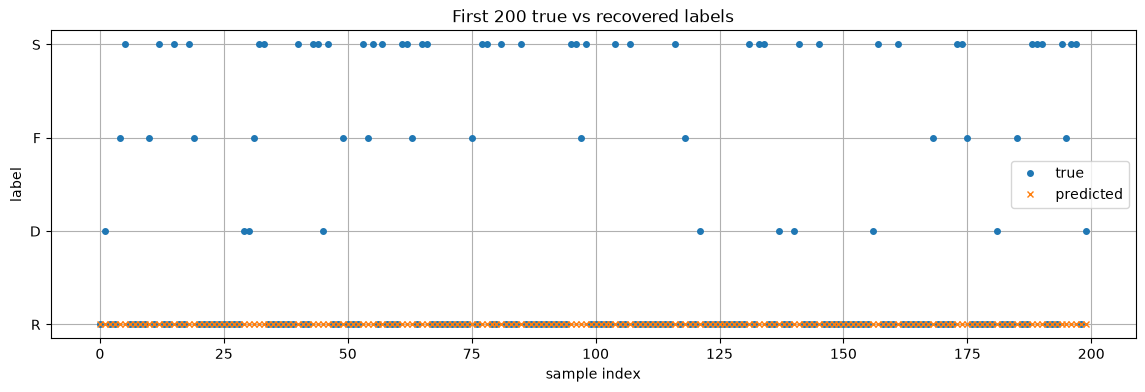

In [ ]:
true_labels = onehot_to_labels(y_test_1)
pred_labels = recovered_labels

n = min(200, len(true_labels))
label_to_num = {label: i for i, label in enumerate(label_map)}

true_nums = [label_to_num[label] for label in true_labels[:n]]
pred_nums = [label_to_num[label] for label in pred_labels[:n]]

plt.figure(figsize=(14, 4))
plt.plot(true_nums, label='true', marker='o', linestyle='None', markersize=4)
plt.plot(pred_nums, label='predicted', marker='x', linestyle='None', markersize=4)
plt.yticks(range(len(label_map)), label_map)
plt.xlabel('sample index')
plt.ylabel('label')
plt.title(f'First {n} true vs recovered labels')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

y_pred_probs = model.predict(X_test_1)
y_pred = onehot_to_labels(y_pred_probs[:, 0:4])
y_true = onehot_to_labels(y_test_1[:, 0:4])

report = classification_report(
    y_true,
    y_pred,
    labels=label_map,
    target_names=label_map,
    zero_division=0,
)

cm = confusion_matrix(y_true, y_pred, labels=label_map)

tps = np.diag(cm)
fps = cm.sum(axis=0) - tps
fns = cm.sum(axis=1) - tps
tns = cm.sum() - (tps + fps + fns)

fpr = np.divide(fps, fps + tns, out=np.zeros_like(fps, dtype=float), where=(fps + tns) != 0)
fnr = np.divide(fns, fns + tps, out=np.zeros_like(fns, dtype=float), where=(fns + tps) != 0)

print("Classification report:")
print(report)
print("Confusion matrix:")
print(cm)

precision = precision_score(y_true, y_pred, labels=label_map, average=None, zero_division=0)
recall = recall_score(y_true, y_pred, labels=label_map, average=None, zero_division=0)
f1 = f1_score(y_true, y_pred, labels=label_map, average=None, zero_division=0)

for label, p, r, f, fp_rate, fn_rate in zip(label_map, precision, recall, f1, fpr, fnr):
    print(
        f"{label}: precision={p:.4f}, recall={r:.4f}, "
        f"f1={f:.4f}, false positive rate={fp_rate:.4f}, false negative rate={fn_rate:.4f}"
    )

8678/8678 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
Classification report:
              precision    recall  f1-score   support

           R       1.00      1.00      1.00    169073
           D       1.00      1.00      1.00     21323
           F       1.00      1.00      1.00     25664
           S       1.00      1.00      1.00     61619

    accuracy                           1.00    277679
   macro avg       1.00      1.00      1.00    277679
weighted avg       1.00      1.00      1.00    277679

Confusion matrix:
[[169070      0      2      1]
 [   103  21220      0      0]
 [   128      0  25536      0]
 [   125      0      0  61494]]
R: precision=0.9979, recall=1.0000, f1=0.9989, false positive rate=0.0033, false negative rate=0.0000
D: precision=1.0000, recall=0.9952, f1=0.9976, false positive rate=0.0000, false negative rate=0.0048
F: precision=0.9999, recall=0.9950, f1=0.9975, false positive rate=0.0000, false negative rate=0.0050
S: precision=1.0000, recall=0.9980, f1=0.9990, fa